<a href="https://colab.research.google.com/github/SHAKSAM03/Energy-Consumption-Time-Series-Forecasting-/blob/main/Energy-Consumption-Time-Series-Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/MES_1225.csv", encoding='latin1')

df.columns = df.columns.str.strip()

df['Time'] = pd.to_datetime(df['Time'], format='%b-%y')

In [ ]:
df = df[
    (df['Country'] == 'India') &
    (df['Product'] == 'Electricity') &
    (df['Balance'] == 'Net Electricity Production')
]

In [ ]:
ts = df.groupby('Time')['Value'].sum()

ts = ts.sort_index()

# set monthly frequency
ts = ts.asfreq('MS')

# fill missing values
ts = ts.interpolate()

print(len(ts))   # must be > 20

132


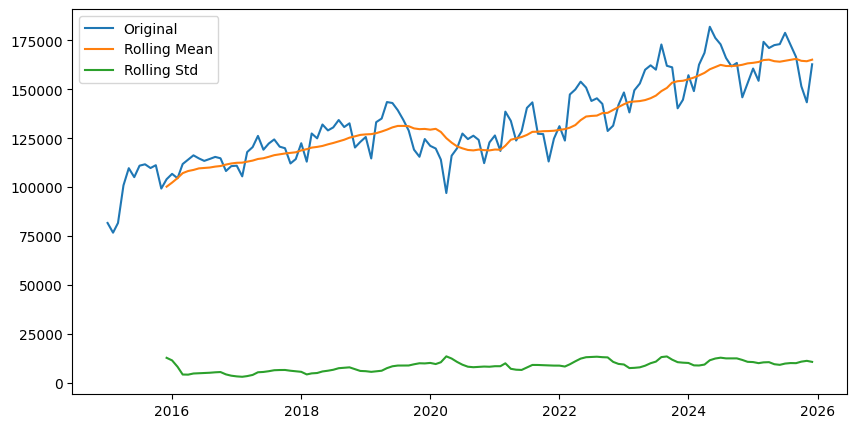

In [ ]:
rolling_mean = ts.rolling(12).mean()
rolling_std = ts.rolling(12).std()

plt.figure(figsize=(10,5))
plt.plot(ts, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series):
    statistic, p_value, _, _ = kpss(series, regression='c')
    print('KPSS Statistic:', statistic)
    print('p-value:', p_value)

kpss_test(ts)

KPSS Statistic: 1.7160560473233428
p-value: 0.01


/tmp/ipykernel_739/1635046629.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, _, _ = kpss(series, regression='c')


In [ ]:
ts_diff = ts.diff().dropna()

In [ ]:
kpss_test(ts_diff)

KPSS Statistic: 0.040773132597526136
p-value: 0.1


/tmp/ipykernel_739/1635046629.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, _ = kpss(series, regression='c')


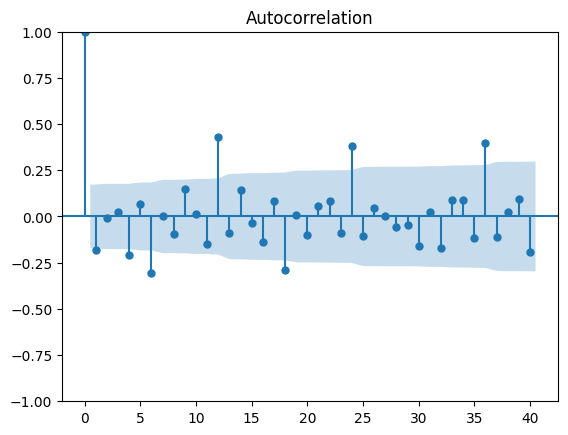

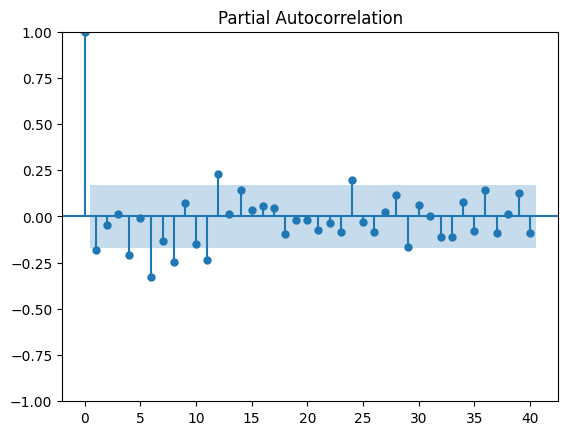

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=40)
plot_pacf(ts_diff, lags=40)
plt.show()

In [ ]:
!pip install pmdarima

from pmdarima import auto_arima

auto_model = auto_arima(ts,
                        seasonal=True,
                        m=12,
                        trace=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2721.986, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2746.806, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2731.149, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2733.891, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2745.499, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=2736.297, Time=0.53 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=2732.390, Time=0.52 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2722.945, Time=1.59 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=2723.126, Time=1.48 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=2734.903, Time=1.62 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=2728.759, Time=1.04 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=5.96 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=2712.455, Time=1.03 sec
 ARIMA(1,1,2)(0,0,1)[12] inte

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(ts,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order)

results = model.fit()

print(results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  132
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1350.924
Date:                              Wed, 01 Apr 2026   AIC                           2713.848
Time:                                      09:21:58   BIC                           2731.099
Sample:                                  01-01-2015   HQIC                          2720.858
                                       - 12-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7417      0.238     -3.123      0.002      -1.207      -0.276
ma.L1          0.68

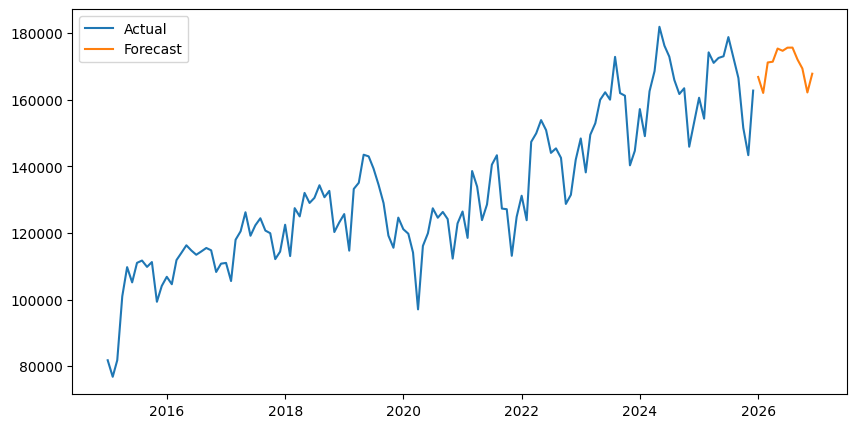

In [ ]:
forecast = results.get_forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

train = ts[:int(0.8*len(ts))]
test = ts[int(0.8*len(ts)):]

model = SARIMAX(train,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order)

results = model.fit()

pred = results.get_forecast(steps=len(test))
y_pred = pred.predicted_mean

rmse = np.sqrt(mean_squared_error(test, y_pred))
mape = mean_absolute_percentage_error(test, y_pred)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 11265.493675802329
MAPE: 0.05827326394497513


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ts_scaled = scaler.fit_transform(ts.values.reshape(-1,1))

In [ ]:
train_size = int(len(ts_scaled) * 0.8)

train = ts_scaled[:train_size]
test = ts_scaled[train_size:]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order)

results = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_scaled = np.sqrt(mean_squared_error(test, y_pred))

print("RMSE (MinMax Scaled):", rmse_scaled)

RMSE (MinMax Scaled): 169917.1106785986


In [ ]:
pred = results.get_forecast(steps=len(test))
y_pred = pred.predicted_mean

In [ ]:
y_pred_actual = scaler.inverse_transform(y_pred.values.reshape(-1,1))

In [ ]:
test_actual = scaler.inverse_transform(test.reshape(-1,1))

In [ ]:
y_pred_actual = scaler.inverse_transform(y_pred.values.reshape(-1,1))
test_actual = scaler.inverse_transform(test.reshape(-1,1))

rmse_actual = np.sqrt(mean_squared_error(test_actual, y_pred_actual))

print("RMSE (Original):", rmse_actual)

RMSE (Original): 17868469374.78322
